In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
aum = pd.read_csv("../data/processed/clean_aum.csv")
sip = pd.read_csv("../data/processed/clean_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

aum["date"] = pd.to_datetime(aum["date"])
sip["month"] = pd.to_datetime(sip["month"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [3]:
top_aum = (
    aum.groupby("fund_house")["aum_crore"]
       .mean()
       .sort_values(ascending=False)
)

top_aum.head(10)

fund_house
SBI Mutual Fund             943444.444444
ICICI Prudential MF         699222.222222
HDFC Mutual Fund            636888.888889
Nippon India MF             434333.333333
Kotak Mahindra MF           389111.111111
Aditya Birla Sun Life MF    341888.888889
UTI Mutual Fund             297888.888889
Axis Mutual Fund            280111.111111
Mirae Asset MF              173444.444444
DSP Mutual Fund             156555.555556
Name: aum_crore, dtype: float64

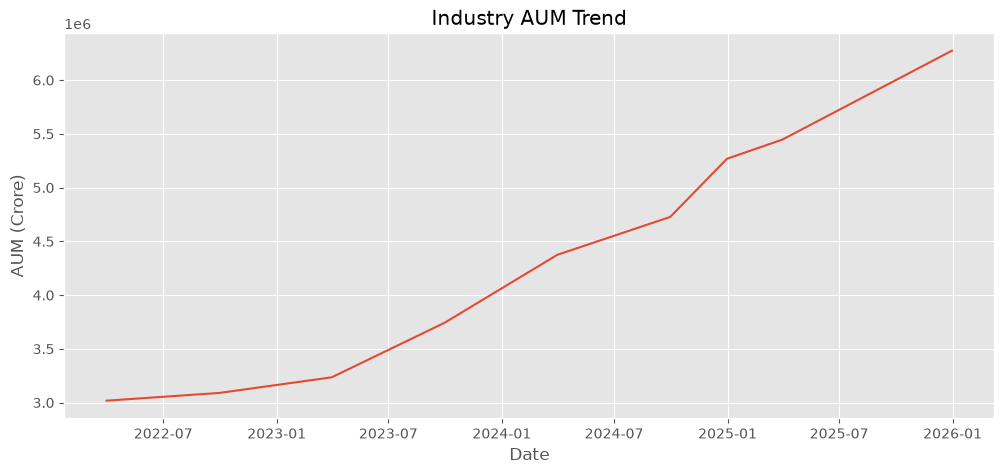

In [4]:
daily_aum = (
    aum.groupby("date")["aum_crore"]
       .sum()
)

plt.figure(figsize=(12,5))

plt.plot(daily_aum.index, daily_aum.values)

plt.title("Industry AUM Trend")
plt.xlabel("Date")
plt.ylabel("AUM (Crore)")

plt.show()

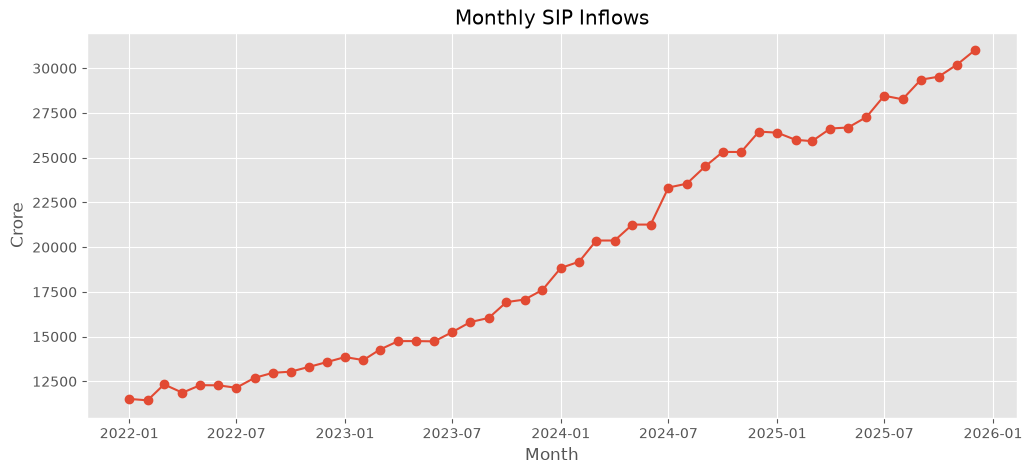

In [5]:
plt.figure(figsize=(12,5))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("Crore")

plt.show()

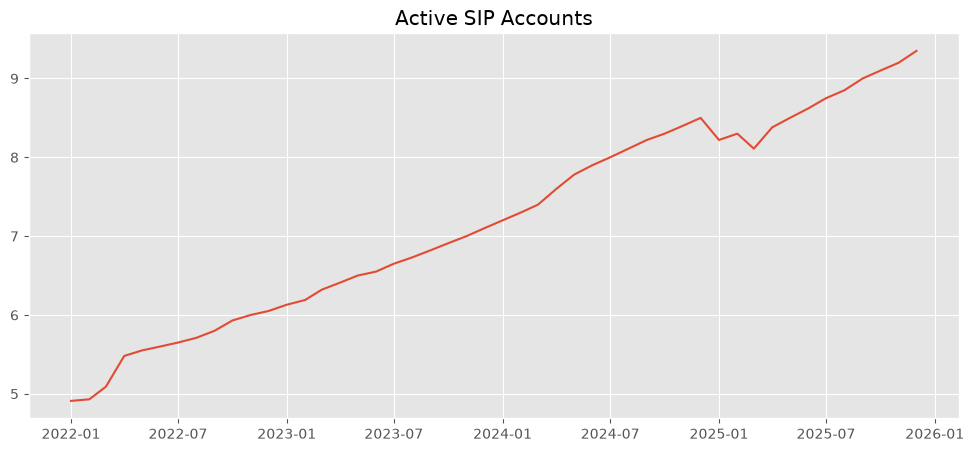

In [6]:
plt.figure(figsize=(12,5))

plt.plot(
    sip["month"],
    sip["active_sip_accounts_crore"]
)

plt.title("Active SIP Accounts")

plt.show()

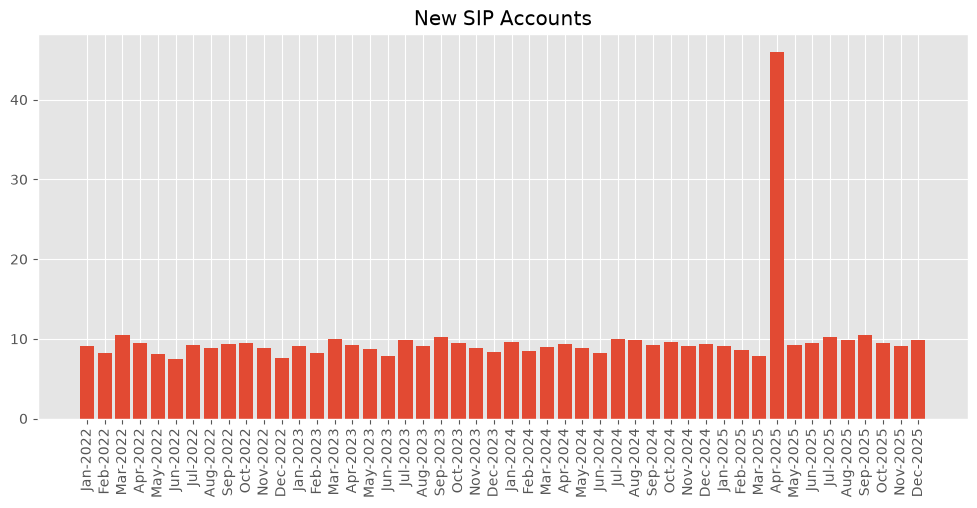

In [7]:
plt.figure(figsize=(12,5))

plt.bar(
    sip["month"].dt.strftime("%b-%Y"),
    sip["new_sip_accounts_lakh"]
)

plt.xticks(rotation=90)

plt.title("New SIP Accounts")

plt.show()

In [8]:
category

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0
...,...,...,...
139,2025-03,Sectoral/Thematic,8614.0
140,2025-03,Liquid,38681.0
141,2025-03,Short Duration,4886.0
142,2025-03,Gilt,956.0


In [9]:
category.groupby("category")["net_inflow_crore"] \
        .sum() \
        .sort_values(ascending=False)

category
Liquid               451275.0
Sectoral/Thematic    103829.0
Flexi Cap             63989.0
Large & Mid Cap       57752.0
Short Duration        55530.0
Mid Cap               55312.0
Small Cap             46596.0
Hybrid                38868.0
Large Cap             25633.0
Value/Contra          16980.0
Gilt                  10395.0
ELSS                   6080.0
Name: net_inflow_crore, dtype: float64

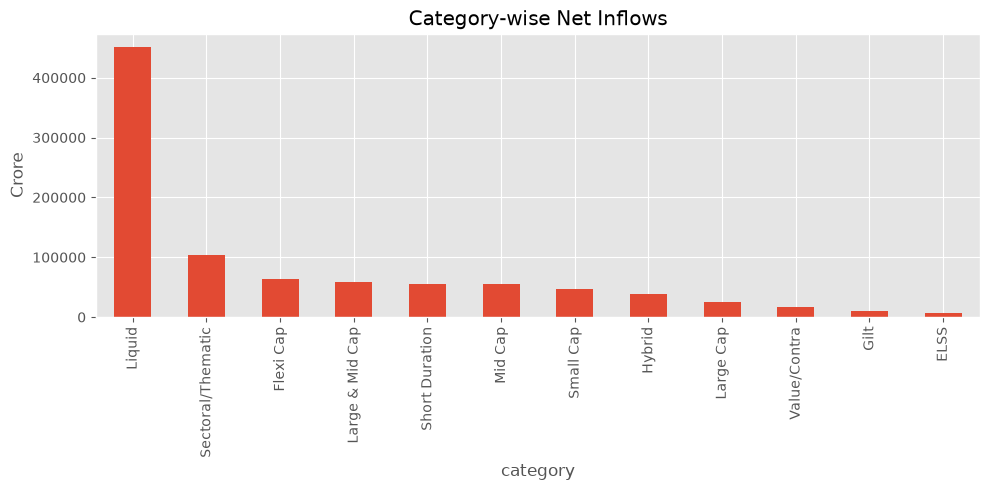

In [10]:
category.groupby("category")["net_inflow_crore"] \
        .sum() \
        .sort_values(ascending=False) \
        .plot(kind="bar", figsize=(10,5))

plt.title("Category-wise Net Inflows")

plt.ylabel("Crore")

plt.tight_layout()

plt.show()

In [11]:
folio

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48
5,2023-04,15.54,10.88,2.18,0.93,1.55
6,2023-07,16.28,11.40,2.28,0.98,1.63
7,2023-10,16.72,11.70,2.34,1.00,1.67
8,2024-01,17.78,12.45,2.49,1.07,1.78
9,2024-04,18.85,13.20,2.64,1.13,1.89


In [14]:
folio.plot(
    x="category",
    y="folio_count_lakh",
    kind="bar",
    figsize=(10,5)
)

plt.title("Industry Folio Count")

plt.ylabel("Lakhs")

plt.tight_layout()

plt.show()

KeyError: 'category'

In [15]:
print(category.columns.tolist())

['month', 'category', 'net_inflow_crore']


In [16]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [17]:
print(folio.columns.tolist())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


In [18]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [19]:
print(folio.columns.tolist())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


In [20]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [21]:
folio["month"] = pd.to_datetime(folio["month"])

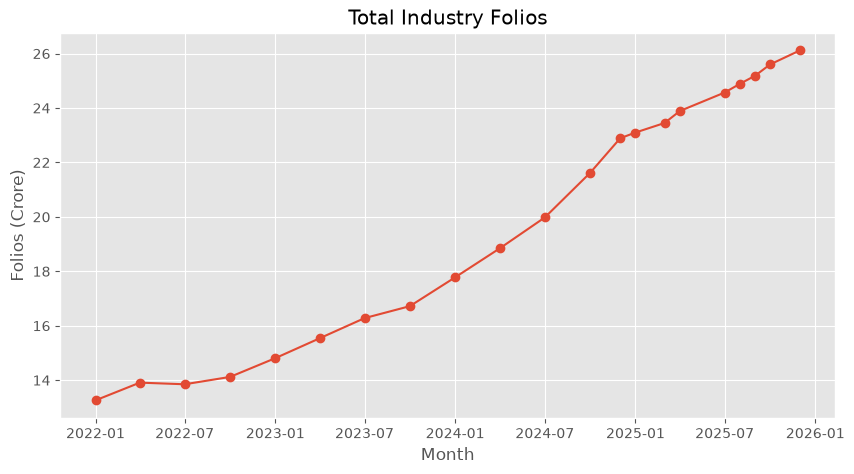

In [22]:
plt.figure(figsize=(10,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Total Industry Folios")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.grid(True)

plt.show()

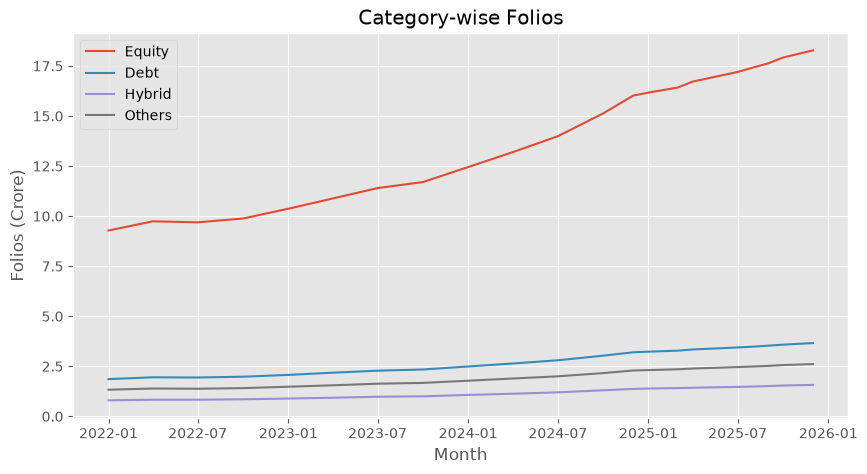

In [23]:
plt.figure(figsize=(10,5))

plt.plot(
    folio["month"],
    folio["equity_folios_crore"],
    label="Equity"
)

plt.plot(
    folio["month"],
    folio["debt_folios_crore"],
    label="Debt"
)

plt.plot(
    folio["month"],
    folio["hybrid_folios_crore"],
    label="Hybrid"
)

plt.plot(
    folio["month"],
    folio["others_folios_crore"],
    label="Others"
)

plt.title("Category-wise Folios")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.legend()

plt.grid(True)

plt.show()